# SINDY PI Applied to Double Pendulum with Friction Simulation

Python implementation of SINDy-PI (Sparse Identification of Nonlinear Dynamics with Parallel Implicit models) applied to a compound double pendulum with viscous friction.

Based on:
- Kaheman, K., Kutz, J.N., & Brunton, S.L. (2020). *SINDy-PI: a robust algorithm for parallel implicit sparse identification of nonlinear dynamics.* Proceedings of the Royal Society A. [doi:10.1098/rspa.2020.0279](https://royalsocietypublishing.org/doi/10.1098/rspa.2020.0279)
- MATLAB reference: [github.com/dynamicslab/SINDy-PI](https://github.com/dynamicslab/SINDy-PI)

SINDy PI Equation:

$$\theta_k(\mathbf{x}, \dot{\mathbf{x}}) = \Theta'(\mathbf{x}, \dot{\mathbf{x}}) \cdot \boldsymbol{\xi}_k$$

Each library term is tested as a candidate LHS. The matching term is excluded from the RHS library, and STLS finds a sparse coefficient vector. This converts the implicit identification problem into a standard (convex) sparse regression, enabling discovery of rational/implicit dynamics like those arising from mass matrix coupling in the double pendulum.

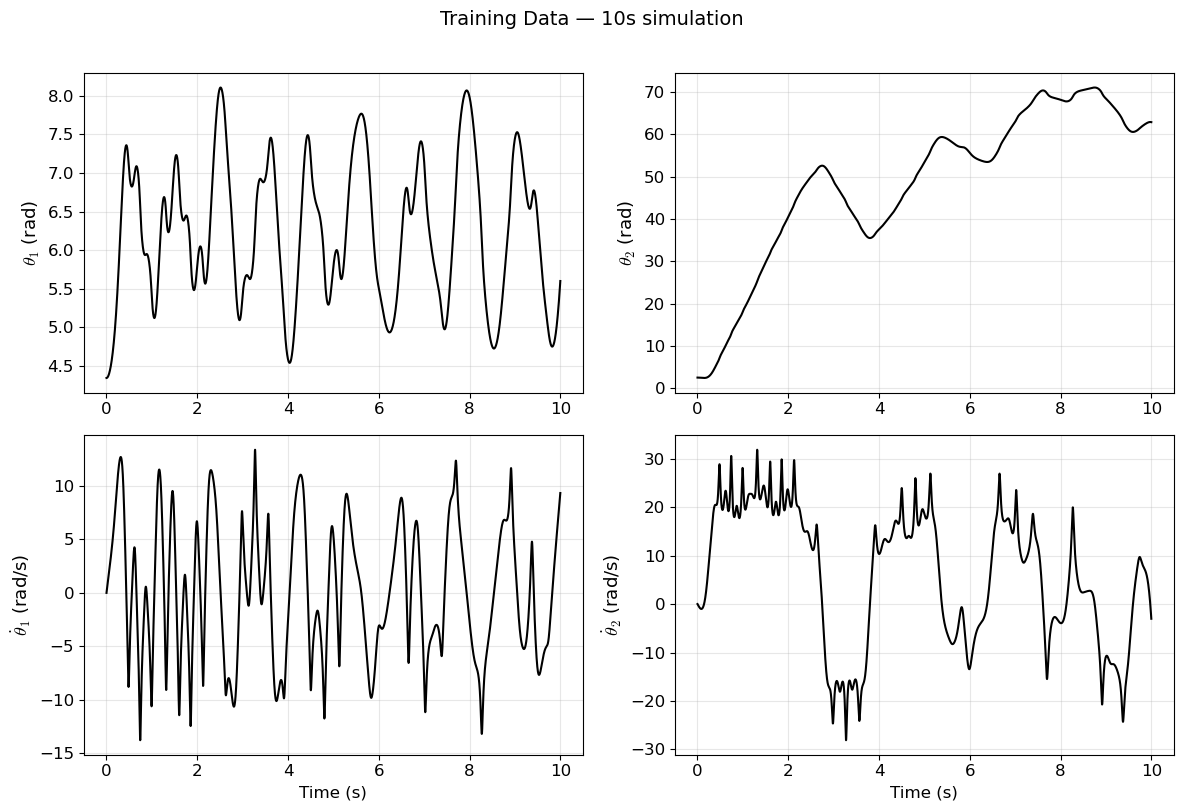

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

plt.rcParams.update({'font.size': 12, 'text.usetex': False,
                     'mathtext.fontset': 'cm', 'figure.dpi': 100})

def double_pendulum_ode(t, y, m1, m2, a1, a2, L1, I1, I2, k1, k2, g):
    """
    ODE function for a damped double pendulum system.
    y = [phi1, phi2, phi1_dot, phi2_dot]
    """
    phi1, phi2, phi1_dot, phi2_dot = y
    d = phi1 - phi2

    # Mass matrix
    M11 = I1 + m1*a1**2 + m2*L1**2
    M12 = m2*L1*a2*np.cos(d)
    M22 = I2 + m2*a2**2
    det_M = M11*M22 - M12**2

    # Generalized friction forces
    # k1: viscous damping at pivot 1 (absolute)
    # k2: viscous damping at pivot 2 (relative velocity)
    Q1 = -k1*phi1_dot - k2*(phi1_dot - phi2_dot)
    Q2 = k2*(phi1_dot - phi2_dot)

    # Coriolis + gravity + friction
    f1 = Q1 - m2*L1*a2*np.sin(d)*phi2_dot**2 - (m1*a1 + m2*L1)*g*np.sin(phi1)
    f2 = Q2 + m2*L1*a2*np.sin(d)*phi1_dot**2 - m2*a2*g*np.sin(phi2)

    # Cramer's rule: ddq = M^{-1} @ f
    phi1_ddot = ( M22*f1 - M12*f2) / det_M
    phi2_ddot = (-M12*f1 + M11*f2) / det_M

    dydt = [phi1_dot, phi2_dot, phi1_ddot, phi2_ddot]
    return dydt


# Parameters (experimentally identified, Kaheman et al. 2020)
m1, m2 = 0.2704, 0.2056
a1, a2 = 0.191, 0.1621
L1 = 0.2667
I1, I2 = 0.003, 0.0011
k1, k2 = 0.00072484, 0.00016522
g = 9.81

dt = 0.001

# Training data: 10s, large initial displacement
y0_train = [np.pi + 1.2, np.pi - 0.6, 0, 0]
t_span_train = (0, 10)
t_train = np.arange(0, 10, dt)
sol_train = solve_ivp(double_pendulum_ode, t_span_train, y0_train,
                      args=(m1, m2, a1, a2, L1, I1, I2, k1, k2, g),
                      t_eval=t_train, rtol=1e-10, atol=1e-12)

# Test data: 3s, different IC with nonzero initial velocity (for model selection)
y0_test = [np.pi - 1.0, np.pi - 0.4, 0.3, 0.4]
t_test = np.arange(0, 3, dt)
sol_test = solve_ivp(double_pendulum_ode, (0, 3), y0_test,
                     args=(m1, m2, a1, a2, L1, I1, I2, k1, k2, g),
                     t_eval=t_test, rtol=1e-10, atol=1e-12)

# Validation data: 15s, third IC (for final comparison)
y0_val = [np.pi + 0.3, np.pi - 0.5, 0, 0]
t_val = np.arange(0, 15, dt)
sol_val = solve_ivp(double_pendulum_ode, (0, 15), y0_val,
                    args=(m1, m2, a1, a2, L1, I1, I2, k1, k2, g),
                    t_eval=t_val, rtol=1e-10, atol=1e-12)

# Plot training data — one panel per state variable (matching MATLAB style)
fig, axs = plt.subplots(2, 2, figsize=(12, 8))

state_labels = [r'$\theta_1$ (rad)', r'$\theta_2$ (rad)',
                r'$\dot{\theta}_1$ (rad/s)', r'$\dot{\theta}_2$ (rad/s)']
for i, (ax, label) in enumerate(zip(axs.flat, state_labels)):
    ax.plot(sol_train.t, sol_train.y[i], 'k', lw=1.5)
    ax.set_ylabel(label, fontsize=13)
    ax.grid(True, alpha=0.3)
    if i >= 2:
        ax.set_xlabel('Time (s)', fontsize=12)

plt.suptitle('Training Data — 10s simulation', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

Step 1: Define the state (X) and compute derivatives (X_dot) including accelerations

For SINDy-PI, the library needs acceleration terms ($\ddot\phi_1$, $\ddot\phi_2$) alongside positions and velocities. We compute accelerations by evaluating the ODE at each data point — no numerical differentiation needed for clean simulation data.

In [2]:
# Extract full state: X = [phi1, phi2, phi1_dot, phi2_dot]
X_train = sol_train.y.T
X_test = sol_test.y.T
X_val = sol_val.y.T

# Compute derivatives by evaluating the ODE at each state
# X_dot = [phi1_dot, phi2_dot, phi1_ddot, phi2_ddot]
def compute_derivatives(X):
    X_dot = np.zeros_like(X)
    for i in range(len(X)):
        X_dot[i] = double_pendulum_ode(0, X[i], m1, m2, a1, a2, L1, I1, I2, k1, k2, g)
    return X_dot

X_dot_train = compute_derivatives(X_train)
X_dot_test = compute_derivatives(X_test)
X_dot_val = compute_derivatives(X_val)

print(f'Training:   {X_train.shape[0]} samples, {X_train.shape[1]} states')
print(f'Test:       {X_test.shape[0]} samples')
print(f'Validation: {X_val.shape[0]} samples')

Training:   10000 samples, 4 states
Test:       3000 samples
Validation: 15000 samples


In [3]:
# Create a pandas DataFrame for display purposes
df_X = pd.DataFrame(X_train[:5], columns=['phi1', 'phi2', 'phi1_dot', 'phi2_dot'])
df_X_dot = pd.DataFrame(X_dot_train[:5], columns=['phi1_dot', 'phi2_dot', 'phi1_ddot', 'phi2_ddot'])

print('State (X):')
display(df_X)
print('\nDerivatives (X_dot), including accelerations:')
display(df_X_dot)

State (X):


,phi1,phi2,phi1_dot,phi2_dot
0,4.341593,2.541593,0.000000,0.000000
1,4.341610,2.541584,0.034110,-0.017795
2,4.341661,2.541557,0.068218,-0.035585
3,4.341746,2.541513,0.102327,-0.053364
4,4.341866,2.541450,0.136435,-0.071128



Derivatives (X_dot), including accelerations:


,phi1_dot,phi2_dot,phi1_ddot,phi2_ddot
0,0.000000,0.000000,34.110109,-17.796767
1,0.034110,-0.017795,34.109135,-17.793393
2,0.068218,-0.035585,34.108495,-17.785199
3,0.102327,-0.053364,34.108190,-17.772187
4,0.136435,-0.071128,34.108221,-17.754357


Step 2: Build the candidate library Theta(X)

The RHS library uses domain-informed angle basis vectors and includes:
- Trig functions: sin, cos, cos² of angle combinations
- Angular velocity terms and velocity × trig products
- **Acceleration × cos² terms** — these are the key addition that enables rational model discovery

The LHS guesses are candidate expressions for the left-hand side of the implicit equation:
- Bare acceleration (→ explicit model)
- Acceleration × cos² multipliers (→ rational model with denominator)

In [4]:
def build_rhs_library(X, X_dot, eq_idx):
    """
    Build the RHS candidate library for SINDy-PI.
    eq_idx: 0 for phi1_ddot equation, 1 for phi2_ddot equation
    """
    phi1, phi2 = X[:, 0], X[:, 1]
    phi1_dot, phi2_dot = X[:, 2], X[:, 3]
    ddq = X_dot[:, eq_idx + 2]  # acceleration for this equation
    ddq_name = ['phi1_ddot', 'phi2_ddot'][eq_idx]

    # Angle basis vectors (following the MATLAB implementation)
    basis = {
        'phi1': phi1, 'phi2': phi2,
        'phi1-phi2': phi1 - phi2,
        'phi1-2*phi2': phi1 - 2*phi2,
        '2*phi1-phi2': 2*phi1 - phi2,
        '2*phi1-2*phi2': 2*(phi1 - phi2),
    }
    all_keys = list(basis.keys())
    diff_keys = all_keys[2:]  # difference-angle bases only

    labels, cols = [], []

    # sin and cos of all 6 bases
    for k in all_keys:
        labels.append(f'sin({k})');  cols.append(np.sin(basis[k]))
    for k in all_keys:
        labels.append(f'cos({k})');  cols.append(np.cos(basis[k]))

    # cos^2 of difference angles
    for k in diff_keys:
        labels.append(f'cos({k})^2');  cols.append(np.cos(basis[k])**2)

    # Angular velocities
    labels += ['phi1_dot', 'phi2_dot']
    cols += [phi1_dot.copy(), phi2_dot.copy()]

    # velocity * sin(difference angle)
    for vn, v in [('phi1_dot', phi1_dot), ('phi2_dot', phi2_dot)]:
        for k in diff_keys:
            labels.append(f'{vn}*sin({k})');  cols.append(v * np.sin(basis[k]))

    # velocity^2 * sin(difference angle)
    for vn, v in [('phi1_dot', phi1_dot), ('phi2_dot', phi2_dot)]:
        for k in diff_keys:
            labels.append(f'{vn}^2*sin({k})');  cols.append(v**2 * np.sin(basis[k]))

    # acceleration * cos^2(difference angle) — enables rational structure
    for k in diff_keys:
        labels.append(f'{ddq_name}*cos({k})^2')
        cols.append(ddq * np.cos(basis[k])**2)

    # constant
    labels.append('1');  cols.append(np.ones(len(phi1)))

    return labels, np.column_stack(cols)


def build_lhs_guesses(X, X_dot, eq_idx):
    """
    Build LHS guess candidates for SINDy-PI.
    Bare acceleration → explicit model; acceleration * cos^2 → rational model.
    """
    phi1, phi2 = X[:, 0], X[:, 1]
    ddq = X_dot[:, eq_idx + 2]
    ddq_name = ['phi1_ddot', 'phi2_ddot'][eq_idx]

    diff_bases = {
        'phi1-phi2': phi1 - phi2,
        'phi1-2*phi2': phi1 - 2*phi2,
        '2*phi1-phi2': 2*phi1 - phi2,
        '2*phi1-2*phi2': 2*(phi1 - phi2),
    }

    labels = [ddq_name]
    data = [ddq.copy()]

    for k, v in diff_bases.items():
        labels.append(f'{ddq_name}*cos({k})^2')
        data.append(ddq * np.cos(v)**2)

    return labels, data


# Build and display the library for the first equation
term_labels, Theta_X = build_rhs_library(X_train, X_dot_train, 0)
lhs_labels, _ = build_lhs_guesses(X_train, X_dot_train, 0)

print(f'RHS library: {len(term_labels)} candidate terms')
print(f'LHS guesses: {len(lhs_labels)} candidates per equation')
print(f'\nRHS terms: {term_labels}')
print(f'\nLHS guesses: {lhs_labels}')

RHS library: 39 candidate terms
LHS guesses: 5 candidates per equation

RHS terms: ['sin(phi1)', 'sin(phi2)', 'sin(phi1-phi2)', 'sin(phi1-2*phi2)', 'sin(2*phi1-phi2)', 'sin(2*phi1-2*phi2)', 'cos(phi1)', 'cos(phi2)', 'cos(phi1-phi2)', 'cos(phi1-2*phi2)', 'cos(2*phi1-phi2)', 'cos(2*phi1-2*phi2)', 'cos(phi1-phi2)^2', 'cos(phi1-2*phi2)^2', 'cos(2*phi1-phi2)^2', 'cos(2*phi1-2*phi2)^2', 'phi1_dot', 'phi2_dot', 'phi1_dot*sin(phi1-phi2)', 'phi1_dot*sin(phi1-2*phi2)', 'phi1_dot*sin(2*phi1-phi2)', 'phi1_dot*sin(2*phi1-2*phi2)', 'phi2_dot*sin(phi1-phi2)', 'phi2_dot*sin(phi1-2*phi2)', 'phi2_dot*sin(2*phi1-phi2)', 'phi2_dot*sin(2*phi1-2*phi2)', 'phi1_dot^2*sin(phi1-phi2)', 'phi1_dot^2*sin(phi1-2*phi2)', 'phi1_dot^2*sin(2*phi1-phi2)', 'phi1_dot^2*sin(2*phi1-2*phi2)', 'phi2_dot^2*sin(phi1-phi2)', 'phi2_dot^2*sin(phi1-2*phi2)', 'phi2_dot^2*sin(2*phi1-phi2)', 'phi2_dot^2*sin(2*phi1-2*phi2)', 'phi1_ddot*cos(phi1-phi2)^2', 'phi1_ddot*cos(phi1-2*phi2)^2', 'phi1_ddot*cos(2*phi1-phi2)^2', 'phi1_ddot*cos(2*p

In [5]:
# Create a pandas DataFrame for display purposes
library_df = pd.DataFrame(Theta_X[:5], columns=term_labels)

print("Candidate Library (Theta) — first 5 rows:")
display(library_df)

Candidate Library (Theta) — first 5 rows:


,sin(phi1),sin(phi2),sin(phi1-phi2),sin(phi1-2*phi2),sin(2*phi1-phi2),sin(2*phi1-2*phi2),cos(phi1),cos(phi2),cos(phi1-phi2),cos(phi1-2*phi2),...,phi1_dot^2*sin(2*phi1-2*phi2),phi2_dot^2*sin(phi1-phi2),phi2_dot^2*sin(phi1-2*phi2),phi2_dot^2*sin(2*phi1-phi2),phi2_dot^2*sin(2*phi1-2*phi2),phi1_ddot*cos(phi1-phi2)^2,phi1_ddot*cos(phi1-2*phi2)^2,phi1_ddot*cos(2*phi1-phi2)^2,phi1_ddot*cos(2*phi1-2*phi2)^2,1
0,-0.932039,0.564642,0.973848,-0.675463,-0.141120,-0.442520,-0.362358,-0.825336,-0.227202,0.737394,...,-0.000000,0.000000,-0.000000,-0.000000,-0.000000,1.760791,18.547354,33.430811,27.430519,1.0
1,-0.932045,0.564650,0.973842,-0.675437,-0.141077,-0.442567,-0.362342,-0.825331,-0.227227,0.737417,...,-0.000515,0.000308,-0.000214,-0.000045,-0.000140,1.761132,18.548009,33.430266,27.428331,1.0
2,-0.932064,0.564672,0.973824,-0.675360,-0.140950,-0.442707,-0.362294,-0.825316,-0.227303,0.737488,...,-0.002060,0.001233,-0.000855,-0.000178,-0.000561,1.762275,18.551213,33.430868,27.423600,1.0
3,-0.932095,0.564709,0.973795,-0.675232,-0.140737,-0.442939,-0.362215,-0.825290,-0.227430,0.737606,...,-0.004638,0.002773,-0.001923,-0.000401,-0.001261,1.764219,18.556967,33.432614,27.416326,1.0
4,-0.932138,0.564760,0.973753,-0.675052,-0.140439,-0.443265,-0.362103,-0.825255,-0.227606,0.737770,...,-0.008251,0.004926,-0.003415,-0.000711,-0.002243,1.766965,18.565269,33.435503,27.406508,1.0


/home/ryanm/miniconda3/envs/sindy/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/home/ryanm/miniconda3/envs/sindy/lib/python3.14/site-packages/numpy/lib/_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


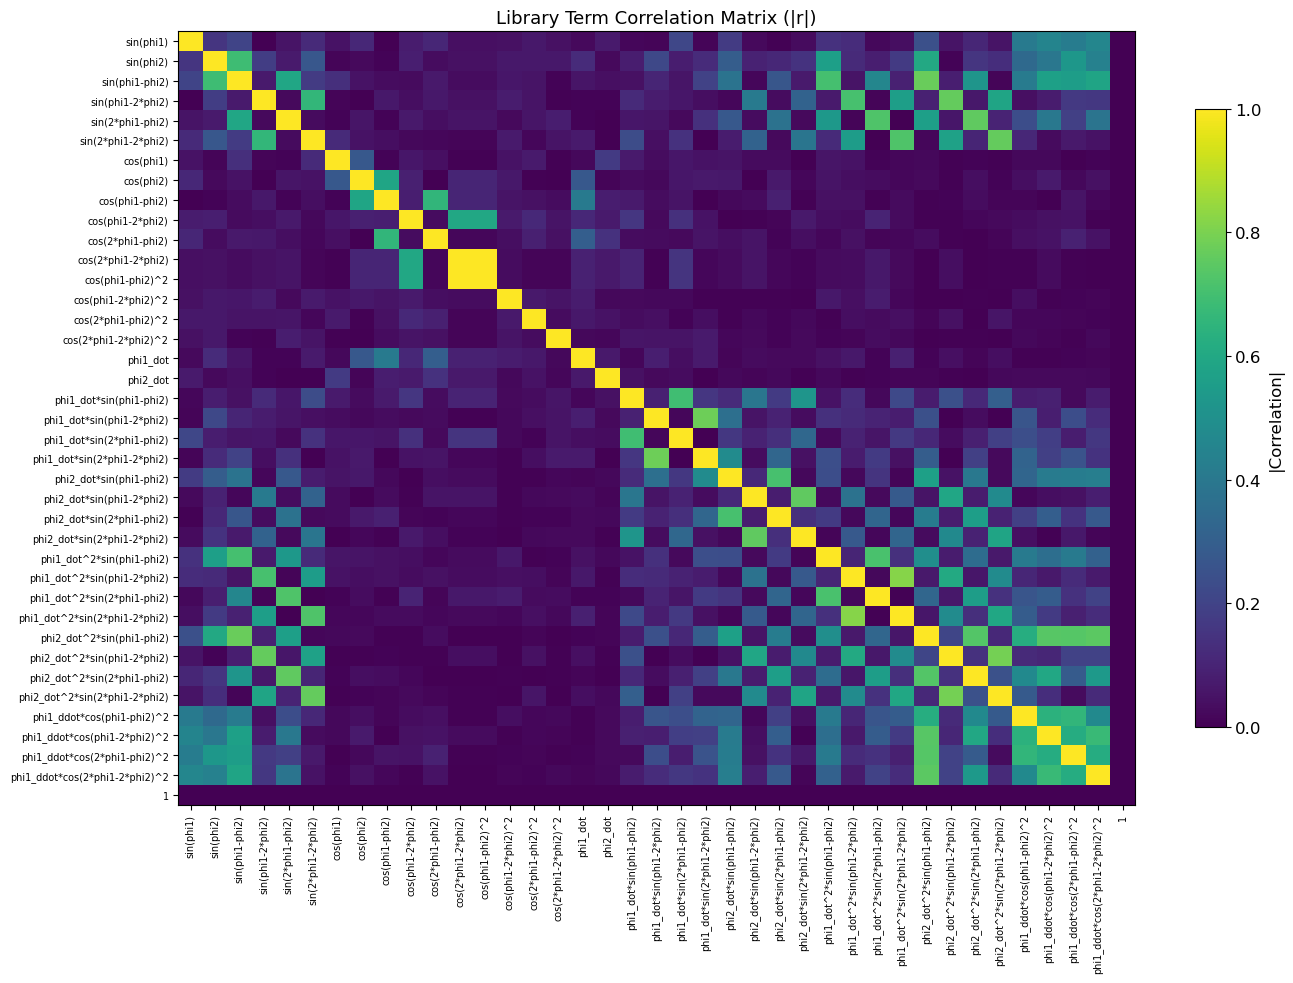

Condition number of library: 1204740534012260352.0


In [6]:
# Visualize the library: heatmap of term correlations
fig, ax = plt.subplots(figsize=(14, 10))
corr = np.corrcoef(Theta_X.T)
corr = np.nan_to_num(corr, nan=0.0)  # constant column ('1') produces NaN
im = ax.imshow(np.abs(corr), cmap='viridis', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(term_labels)))
ax.set_yticks(range(len(term_labels)))
ax.set_xticklabels(term_labels, rotation=90, fontsize=7)
ax.set_yticklabels(term_labels, fontsize=7)
ax.set_title('Library Term Correlation Matrix (|r|)', fontsize=13)
plt.colorbar(im, ax=ax, shrink=0.8, label='|Correlation|')
plt.tight_layout()
plt.show()

print(f'Condition number of library: {np.linalg.cond(Theta_X):.1f}')

Step 3: Sequential Thresholded Least Squares (STLS)

STLS alternates between least-squares regression and hard thresholding to promote sparsity. Coefficients below $\lambda$ are zeroed, and the remaining terms are re-fit.

In [7]:
# Define Sequentially Thresholded Least Squares (STLS)
def stls(Theta, target, lam, max_iter=20):
    """
    Sequentially Thresholded Least Squares for sparse regression.
    Alternates: (1) least-squares solve, (2) zero out |xi| < lambda, (3) re-solve on survivors.
    """
    # Step 1: Initial least-squares solution
    Xi = np.linalg.lstsq(Theta, target, rcond=None)[0]

    # Step 2: Iterative sparsification
    for iteration in range(max_iter):
        small_inds = np.abs(Xi) < lam
        Xi[small_inds] = 0.0
        big_inds = ~small_inds
        if not np.any(big_inds):
            break
        Xi[big_inds] = np.linalg.lstsq(Theta[:, big_inds], target, rcond=None)[0]

    return Xi


# Evaluate model accuracy (L2 Error)
def compute_l2_error(predicted, actual):
    return np.linalg.norm(predicted - actual) / np.linalg.norm(actual)

Step 4: SINDy-PI Main Loop — Parallel Implicit Sparse Regression

For each acceleration equation ($\ddot\phi_1$ and $\ddot\phi_2$):
1. Try each LHS guess (5 candidates)
2. Exclude the matching term from the RHS library
3. Sweep over threshold values $\lambda$
4. Score each model on the held-out test set
5. Select the best (LHS guess, $\lambda$) combination

Calculating equations for both acceleration terms...

Identifying: phi1_ddot
  LHS = phi1_ddot                                 best so far: 0.001210
  LHS = phi1_ddot*cos(phi1-phi2)^2                best so far: 0.001210
  LHS = phi1_ddot*cos(phi1-2*phi2)^2              best so far: 0.001210
  LHS = phi1_ddot*cos(2*phi1-phi2)^2              best so far: 0.001210
  LHS = phi1_ddot*cos(2*phi1-2*phi2)^2            best so far: 0.001210

  >> Best: LHS = phi1_ddot, lambda = 0.005, score = 0.001210, 16 active terms

Identifying: phi2_ddot
  LHS = phi2_ddot                                 best so far: 0.001914
  LHS = phi2_ddot*cos(phi1-phi2)^2                best so far: 0.001914
  LHS = phi2_ddot*cos(phi1-2*phi2)^2              best so far: 0.001914
  LHS = phi2_ddot*cos(2*phi1-phi2)^2              best so far: 0.001914
  LHS = phi2_ddot*cos(2*phi1-2*phi2)^2            best so far: 0.001914

  >> Best: LHS = phi2_ddot, lambda = 0.02, score = 0.001914, 15 active terms


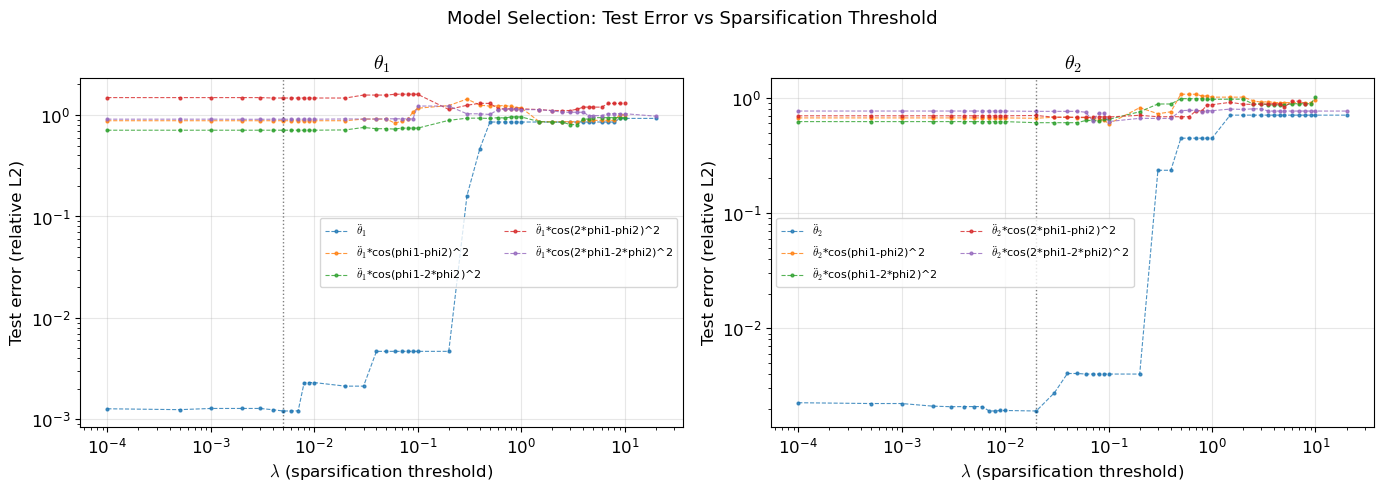


Done.


In [8]:
# Sparsification thresholds to sweep (matching the MATLAB implementation)
lambdas = np.array([
    1e-4, 5e-4, 1e-3, 2e-3, 3e-3, 4e-3, 5e-3, 6e-3, 7e-3, 8e-3, 9e-3,
    1e-2, 2e-2, 3e-2, 4e-2, 5e-2, 6e-2, 7e-2, 8e-2, 9e-2,
    1e-1, 2e-1, 3e-1, 4e-1, 5e-1, 6e-1, 7e-1, 8e-1, 9e-1,
    1, 1.5, 2, 2.5, 3, 3.5, 4, 4.5, 5, 6, 7, 8, 9, 10, 20, 30, 40, 50, 100, 200
])

eq_names = ['phi1_ddot', 'phi2_ddot']
best_models = {}
sweep_results = {}  # track all scores for visualization

print("Calculating equations for both acceleration terms...")

for eq_idx, eq_name in enumerate(eq_names):
    print(f"\n{'='*60}")
    print(f'Identifying: {eq_name}')
    print(f"{'='*60}")

    # Build libraries from training and test data
    rhs_labels, rhs_train = build_rhs_library(X_train, X_dot_train, eq_idx)
    _, rhs_test = build_rhs_library(X_test, X_dot_test, eq_idx)

    lhs_labels, lhs_train_list = build_lhs_guesses(X_train, X_dot_train, eq_idx)
    _, lhs_test_list = build_lhs_guesses(X_test, X_dot_test, eq_idx)

    best_score = np.inf
    sweep_results[eq_name] = []

    for g_idx, lhs_name in enumerate(lhs_labels):
        lhs_train = lhs_train_list[g_idx]
        lhs_test = lhs_test_list[g_idx]

        # Exclude LHS guess from RHS library (prevent trivial identity)
        keep = [i for i, l in enumerate(rhs_labels) if l != lhs_name]
        rhs_labels_excl = [rhs_labels[i] for i in keep]
        rhs_train_excl = rhs_train[:, keep]
        rhs_test_excl = rhs_test[:, keep]

        for lam in lambdas:
            Xi = stls(rhs_train_excl, lhs_train, lam)
            n_terms = np.count_nonzero(Xi)
            if n_terms == 0:
                continue

            # One-step prediction error on test set
            pred = rhs_test_excl @ Xi
            score = compute_l2_error(pred, lhs_test)

            sweep_results[eq_name].append({
                'lhs': lhs_name, 'lam': lam, 'score': score, 'n_terms': n_terms
            })

            if score < best_score:
                best_score = score
                best_models[eq_name] = {
                    'lhs': lhs_name,
                    'rhs_labels': rhs_labels_excl,
                    'Xi': Xi.copy(),
                    'lam': lam,
                    'score': score,
                    'n_terms': n_terms,
                    'rhs_train_excl': rhs_train_excl,
                    'lhs_train': lhs_train,
                }

        print(f'  LHS = {lhs_name:40s}  best so far: {best_score:.6f}')

    m = best_models[eq_name]
    print(f"\n  >> Best: LHS = {m['lhs']}, lambda = {m['lam']}, "
          f"score = {m['score']:.6f}, {m['n_terms']} active terms")

# Visualize the lambda sweep — score vs threshold for each LHS guess
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for eq_idx, eq_name in enumerate(eq_names):
    ax = axes[eq_idx]
    lhs_groups = {}
    for r in sweep_results[eq_name]:
        lhs_groups.setdefault(r['lhs'], ([], []))
        lhs_groups[r['lhs']][0].append(r['lam'])
        lhs_groups[r['lhs']][1].append(r['score'])

    for lhs_name, (lams, scores) in lhs_groups.items():
        short_name = lhs_name.replace('phi1_ddot', r'$\ddot\theta_1$').replace('phi2_ddot', r'$\ddot\theta_2$')
        ax.semilogy(lams, scores, '.--', markersize=4, lw=0.8, label=short_name, alpha=0.8)

    m = best_models[eq_name]
    ax.axvline(m['lam'], color='k', ls=':', lw=1, alpha=0.5)
    ax.set_xlabel(r'$\lambda$ (sparsification threshold)', fontsize=12)
    ax.set_ylabel('Test error (relative L2)', fontsize=12)
    ax.set_title(eq_name.replace('phi1', r'$\theta_1$').replace('phi2', r'$\theta_2$').replace('_ddot', ''))
    ax.legend(fontsize=8, ncol=2)
    ax.set_xscale('log')
    ax.grid(True, alpha=0.3)

plt.suptitle('Model Selection: Test Error vs Sparsification Threshold', fontsize=13)
plt.tight_layout()
plt.show()

print("\nDone.")

Step 5: Refine and Recover Equations

The initial selection minimizes test error, which can retain small spurious terms. We refine by removing coefficients whose magnitude is negligible compared to the dominant terms, then re-fit. This is standard practice — $\lambda$ does the heavy lifting, and a final pass cleans up noise-level residuals.

In [9]:
import sympy as sp

phi1_s, phi2_s = sp.symbols('phi1 phi2')
phi1_dot_s, phi2_dot_s = sp.symbols('phi1_dot phi2_dot')
phi1_ddot_s, phi2_ddot_s = sp.symbols('phi1_ddot phi2_ddot')


def build_sympy_library(eq_idx):
    """Build sympy expressions mirroring the numerical library."""
    ddq = [phi1_ddot_s, phi2_ddot_s][eq_idx]
    ddq_name = ['phi1_ddot', 'phi2_ddot'][eq_idx]

    basis = {
        'phi1': phi1_s, 'phi2': phi2_s,
        'phi1-phi2': phi1_s - phi2_s,
        'phi1-2*phi2': phi1_s - 2*phi2_s,
        '2*phi1-phi2': 2*phi1_s - phi2_s,
        '2*phi1-2*phi2': 2*(phi1_s - phi2_s),
    }
    all_keys = list(basis.keys())
    diff_keys = all_keys[2:]

    sym = {}
    for k in all_keys:
        sym[f'sin({k})'] = sp.sin(basis[k])
        sym[f'cos({k})'] = sp.cos(basis[k])
    for k in diff_keys:
        sym[f'cos({k})^2'] = sp.cos(basis[k])**2
    sym['phi1_dot'] = phi1_dot_s
    sym['phi2_dot'] = phi2_dot_s
    for vn, vs in [('phi1_dot', phi1_dot_s), ('phi2_dot', phi2_dot_s)]:
        for k in diff_keys:
            sym[f'{vn}*sin({k})'] = vs * sp.sin(basis[k])
    for vn, vs in [('phi1_dot', phi1_dot_s), ('phi2_dot', phi2_dot_s)]:
        for k in diff_keys:
            sym[f'{vn}^2*sin({k})'] = vs**2 * sp.sin(basis[k])
    for k in diff_keys:
        sym[f'{ddq_name}*cos({k})^2'] = ddq * sp.cos(basis[k])**2
    sym['1'] = sp.Integer(1)

    lhs_sym = {ddq_name: ddq}
    for k in diff_keys:
        lhs_sym[f'{ddq_name}*cos({k})^2'] = ddq * sp.cos(basis[k])**2

    return sym, lhs_sym


# Refinement threshold — removes noise-level coefficients
COEFF_THRESHOLD = 0.1

recovered_exact = {}
recovered_display = {}

for eq_idx, eq_name in enumerate(eq_names):
    m = best_models[eq_name]
    ddq_name = ['phi1_ddot', 'phi2_ddot'][eq_idx]
    ddq_sym = [phi1_ddot_s, phi2_ddot_s][eq_idx]

    # Identify significant terms and re-fit
    sig_mask = np.abs(m['Xi']) >= COEFF_THRESHOLD
    Xi_refined = np.zeros_like(m['Xi'])
    Xi_refined[sig_mask] = np.linalg.lstsq(
        m['rhs_train_excl'][:, sig_mask], m['lhs_train'], rcond=None
    )[0]

    n_before = m['n_terms']
    n_after = np.count_nonzero(Xi_refined)
    print(f'{eq_name}: {n_before} terms -> {n_after} terms after refinement')

    # Print refined coefficients
    for Xi_j, label in zip(Xi_refined, m['rhs_labels']):
        if abs(Xi_j) > 1e-10:
            print(f'  {Xi_j:+12.6f} * {label}')

    # Build symbolic equation: separate numerator (no accel) from denominator (has accel)
    rhs_sym, lhs_sym = build_sympy_library(eq_idx)

    numer = sp.Float(0)
    denom = sp.Integer(1) if m['lhs'] == ddq_name else lhs_sym[m['lhs']] / ddq_sym

    for Xi_j, label in zip(Xi_refined, m['rhs_labels']):
        if abs(Xi_j) < 1e-10:
            continue
        c = round(float(Xi_j), 4)
        sym_term = rhs_sym[label]

        if ddq_name in label:
            f_x = sym_term / ddq_sym
            denom = denom - c * f_x
        else:
            numer = numer + c * sym_term

    numer = sp.nsimplify(numer, rational=False)
    denom = sp.nsimplify(denom, rational=False)
    explicit = numer / denom

    recovered_exact[eq_name] = explicit
    recovered_display[eq_name] = (numer, denom)

    print(f'\n  {eq_name} = N / D')
    print(f'  N = {numer}')
    print(f'  D = {denom}')
    print()

phi1_ddot: 16 terms -> 5 terms after refinement
    -29.872168 * sin(phi1)
     -8.147316 * sin(phi1-2*phi2)
     -0.220243 * phi1_dot^2*sin(2*phi1-2*phi2)
     -0.323300 * phi2_dot^2*sin(phi1-phi2)
     +0.442425 * phi1_ddot*cos(phi1-phi2)^2

  phi1_ddot = N / D
  N = -1101*phi1_dot**2*sin(2*phi1 - 2*phi2)/5000 - 3233*phi2_dot**2*sin(phi1 - phi2)/10000 - 149361*sin(phi1)/5000 - 81473*sin(phi1 - 2*phi2)/10000
  D = 1 - 553*cos(phi1 - phi2)**2/1250

phi2_ddot: 15 terms -> 5 terms after refinement
    -24.292392 * sin(phi2)
    +25.994190 * sin(2*phi1-phi2)
     +1.365833 * phi1_dot^2*sin(phi1-phi2)
     +0.221014 * phi2_dot^2*sin(2*phi1-2*phi2)
     +0.442126 * phi2_ddot*cos(phi1-phi2)^2

  phi2_ddot = N / D
  N = 6829*phi1_dot**2*sin(phi1 - phi2)/5000 + 221*phi2_dot**2*sin(2*phi1 - 2*phi2)/1000 - 60731*sin(phi2)/2500 + 129971*sin(2*phi1 - phi2)/5000
  D = 1 - 4421*cos(phi1 - phi2)**2/10000



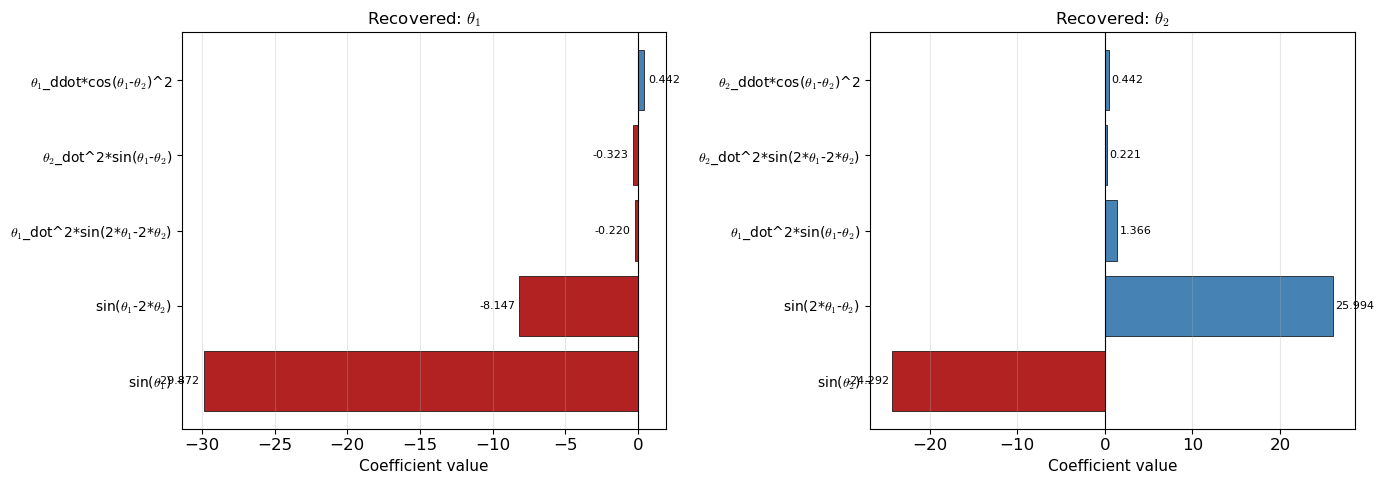

Sparsity pattern:
  phi1_ddot: 5 / 39 terms active (12.8% library utilization)
  phi2_ddot: 5 / 39 terms active (12.8% library utilization)


In [10]:
# Visualize the discovered sparse coefficients
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for eq_idx, eq_name in enumerate(eq_names):
    m = best_models[eq_name]
    sig_mask = np.abs(m['Xi']) >= COEFF_THRESHOLD
    Xi_refined = np.zeros_like(m['Xi'])
    Xi_refined[sig_mask] = np.linalg.lstsq(
        m['rhs_train_excl'][:, sig_mask], m['lhs_train'], rcond=None
    )[0]

    # Only plot nonzero terms
    nonzero = np.abs(Xi_refined) > 1e-10
    active_labels = [m['rhs_labels'][i] for i in range(len(Xi_refined)) if nonzero[i]]
    active_coeffs = Xi_refined[nonzero]

    # Format labels with math notation
    fmt_labels = []
    for l in active_labels:
        fl = l.replace('phi1', r'$\theta_1$').replace('phi2', r'$\theta_2$')
        fl = fl.replace('phi1_dot', r'$\dot\theta_1$').replace('phi2_dot', r'$\dot\theta_2$')
        fl = fl.replace('phi1_ddot', r'$\ddot\theta_1$').replace('phi2_ddot', r'$\ddot\theta_2$')
        fmt_labels.append(fl)

    ax = axes[eq_idx]
    colors = ['steelblue' if c > 0 else 'firebrick' for c in active_coeffs]
    bars = ax.barh(range(len(active_coeffs)), active_coeffs, color=colors, edgecolor='k', lw=0.5)
    ax.set_yticks(range(len(active_coeffs)))
    ax.set_yticklabels(fmt_labels, fontsize=10)
    ax.set_xlabel('Coefficient value', fontsize=11)
    title = eq_name.replace('phi1', r'$\theta_1$').replace('phi2', r'$\theta_2$').replace('_ddot', '')
    ax.set_title(f'Recovered: {title}', fontsize=12)
    ax.axvline(x=0, color='k', linewidth=0.8)
    ax.grid(True, axis='x', alpha=0.3)

    # Annotate coefficient values
    for bar, coeff in zip(bars, active_coeffs):
        x_pos = bar.get_width()
        ax.text(x_pos + (0.3 if x_pos >= 0 else -0.3), bar.get_y() + bar.get_height()/2,
                f'{coeff:.3f}', va='center', ha='left' if x_pos >= 0 else 'right', fontsize=8)

plt.tight_layout()
plt.show()

# Sparsity summary
print('Sparsity pattern:')
for eq_name in eq_names:
    m = best_models[eq_name]
    sig = np.abs(m['Xi']) >= COEFF_THRESHOLD
    print(f'  {eq_name}: {sig.sum()} / {len(m["Xi"])} terms active '
          f'({sig.sum()/len(m["Xi"])*100:.1f}% library utilization)')

Verify Recovered Equation

We simulate the discovered ODE from a held-out validation initial condition and compare against ground truth. The double pendulum is chaotic, so even small modeling errors (like neglected friction) compound exponentially — short-term agreement with eventual long-term divergence is expected.

In [11]:
import warnings
warnings.filterwarnings('ignore', category=RuntimeWarning)

# Convert recovered equations to callable functions
f_ddq1 = sp.lambdify([phi1_s, phi2_s, phi1_dot_s, phi2_dot_s],
                     recovered_exact['phi1_ddot'], 'numpy')
f_ddq2 = sp.lambdify([phi1_s, phi2_s, phi1_dot_s, phi2_dot_s],
                     recovered_exact['phi2_ddot'], 'numpy')


def recovered_ode(t, y):
    phi1, phi2, phi1_dot, phi2_dot = y
    phi1_ddot = float(f_ddq1(phi1, phi2, phi1_dot, phi2_dot))
    phi2_ddot = float(f_ddq2(phi1, phi2, phi1_dot, phi2_dot))
    return [phi1_dot, phi2_dot, phi1_ddot, phi2_ddot]


# Simulate from validation IC
sol_sindy = solve_ivp(recovered_ode, (0, 15), y0_val, t_eval=t_val,
                      method='LSODA', rtol=1e-10, atol=1e-12)

if not sol_sindy.success:
    print(f'Note: SINDy-PI simulation ended at t = {sol_sindy.t[-1]:.2f}s')

# One-step derivative prediction (true metric of model quality)
ddq1_true = X_dot_val[:, 2]
ddq2_true = X_dot_val[:, 3]
ddq1_pred = np.array([f_ddq1(*X_val[i]) for i in range(len(X_val))])
ddq2_pred = np.array([f_ddq2(*X_val[i]) for i in range(len(X_val))])

err1 = compute_l2_error(ddq1_pred, ddq1_true)
err2 = compute_l2_error(ddq2_pred, ddq2_true)
print(f'One-step prediction error (validation set):')
print(f'  phi1_ddot: {err1:.6f} ({err1*100:.3f}%)')
print(f'  phi2_ddot: {err2:.6f} ({err2*100:.3f}%)')

One-step prediction error (validation set):
  phi1_ddot: 0.005325 (0.533%)
  phi2_ddot: 0.007793 (0.779%)


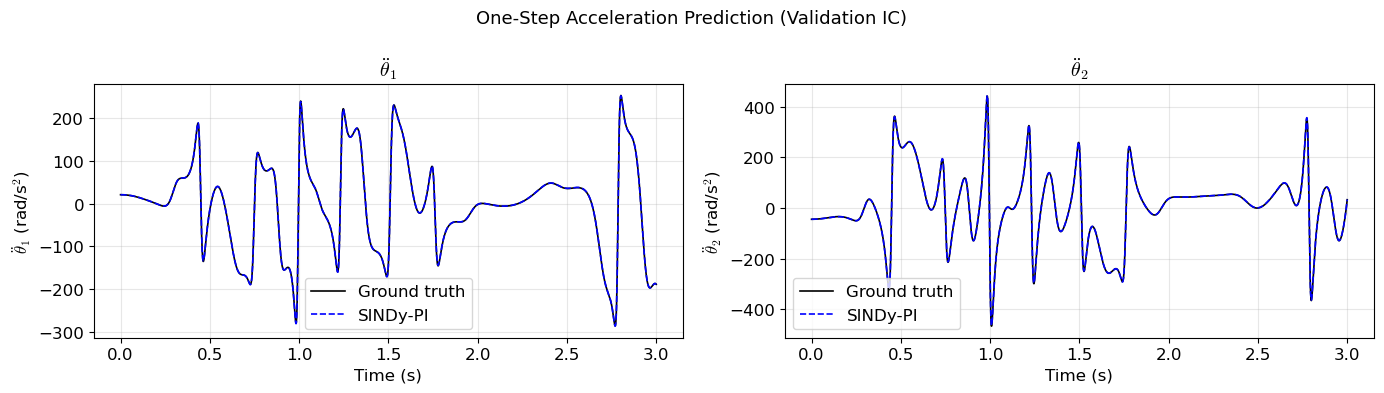

In [12]:
# One-step acceleration prediction — the true metric of model quality
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

t_plot = t_val[:3000]  # first 3 seconds for readability

axes[0].plot(t_plot, ddq1_true[:3000], 'k', lw=1.2, label='Ground truth')
axes[0].plot(t_plot, ddq1_pred[:3000], 'b--', lw=1.2, label='SINDy-PI')
axes[0].set_xlabel('Time (s)'); axes[0].set_ylabel(r'$\ddot{\theta}_1$ (rad/s$^2$)')
axes[0].set_title(r'$\ddot{\theta}_1$'); axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(t_plot, ddq2_true[:3000], 'k', lw=1.2, label='Ground truth')
axes[1].plot(t_plot, ddq2_pred[:3000], 'b--', lw=1.2, label='SINDy-PI')
axes[1].set_xlabel('Time (s)'); axes[1].set_ylabel(r'$\ddot{\theta}_2$ (rad/s$^2$)')
axes[1].set_title(r'$\ddot{\theta}_2$'); axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('One-Step Acceleration Prediction (Validation IC)', fontsize=13)
plt.tight_layout()
plt.show()

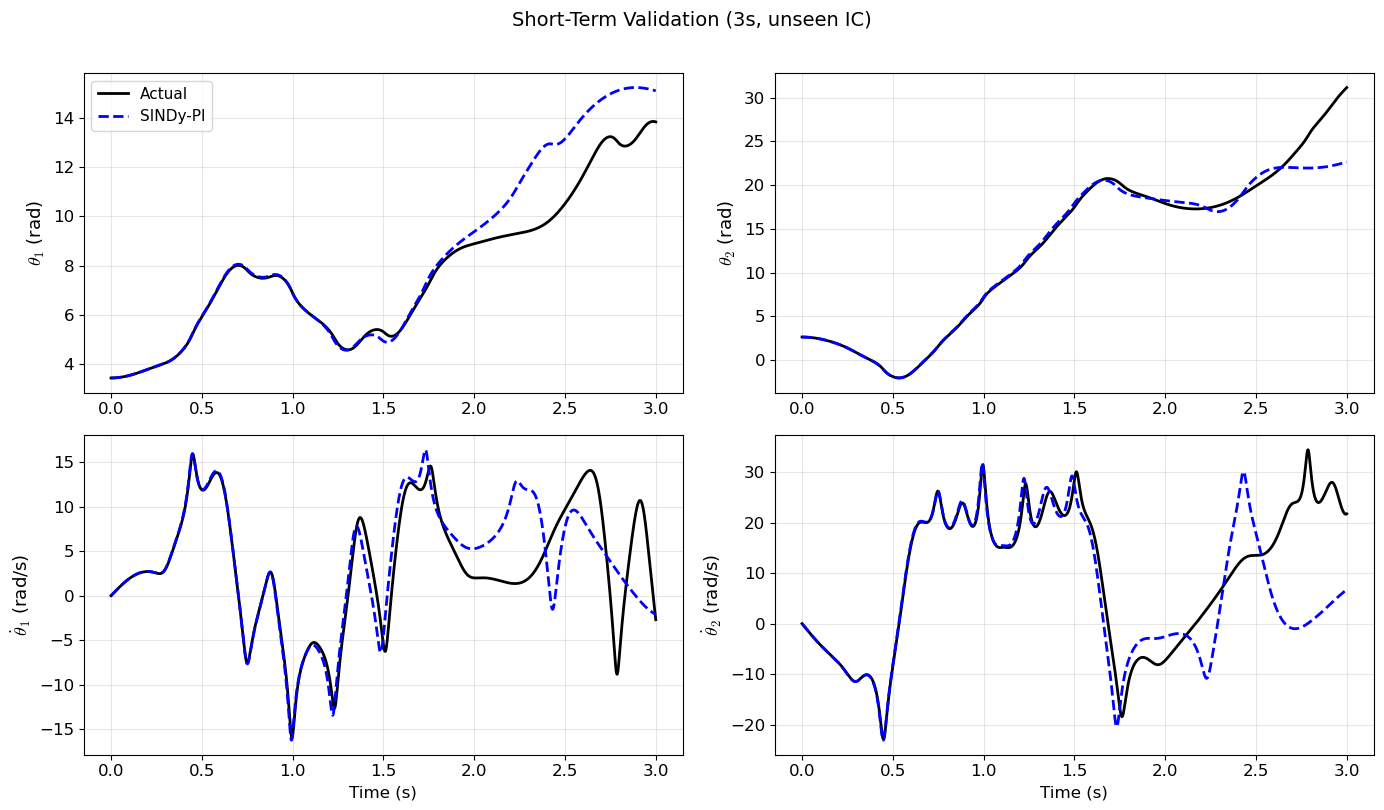

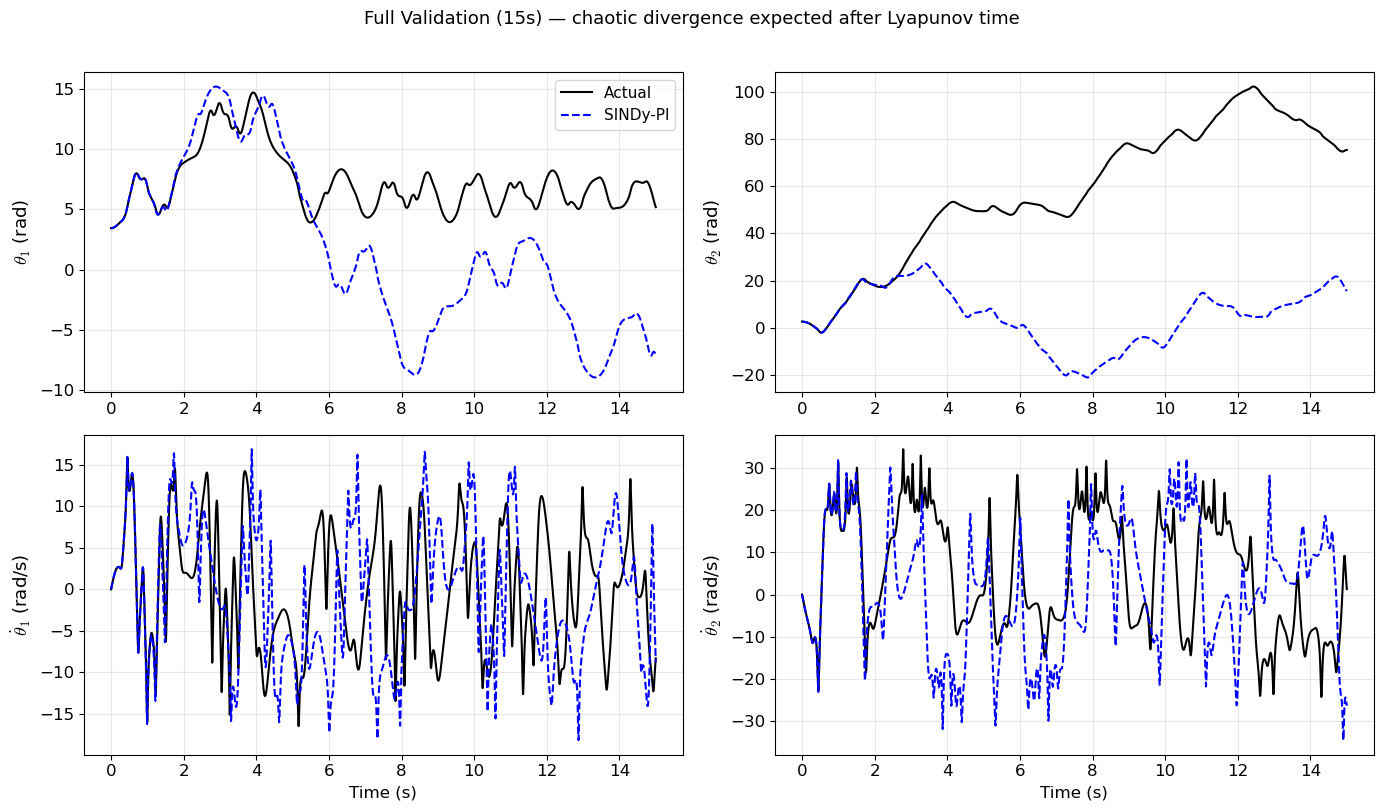

Relative L2 trajectory error by time horizon:
  t= 1s  phi1=0.0046  phi2=0.0147  w1=0.0258  w2=0.0198
  t= 3s  phi1=0.1491  phi2=0.1147  w1=0.5334  w2=0.5545
  t= 5s  phi1=0.1516  phi2=0.6637  w1=0.8496  w2=1.0439
  t=10s  phi1=0.7788  phi2=1.0589  w1=1.2742  w2=1.1067


In [13]:
# Trajectory comparison — MATLAB style: black solid truth, blue dashed SINDy-PI
n = min(len(t_val), len(sol_sindy.t))

# Short-term comparison (3s) — where the model tracks well
fig, axs = plt.subplots(2, 2, figsize=(14, 8))
t_short = 3.0  # seconds
n_short = min(int(t_short / dt), n)

state_labels = [r'$\theta_1$ (rad)', r'$\theta_2$ (rad)',
                r'$\dot{\theta}_1$ (rad/s)', r'$\dot{\theta}_2$ (rad/s)']

for i, (ax, label) in enumerate(zip(axs.flat, state_labels)):
    ax.plot(t_val[:n_short], X_val[:n_short, i], 'k', lw=2, label='Actual')
    ax.plot(sol_sindy.t[:n_short], sol_sindy.y[i, :n_short], 'b--', lw=2, label='SINDy-PI')
    ax.set_ylabel(label, fontsize=13)
    ax.grid(True, alpha=0.3)
    if i >= 2:
        ax.set_xlabel('Time (s)', fontsize=12)
    if i == 0:
        ax.legend(fontsize=11)

plt.suptitle(f'Short-Term Validation ({t_short:.0f}s, unseen IC)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

# Full trajectory comparison (up to 15s) — chaotic divergence is expected
fig, axs = plt.subplots(2, 2, figsize=(14, 8))

for i, (ax, label) in enumerate(zip(axs.flat, state_labels)):
    ax.plot(t_val, X_val[:, i], 'k', lw=1.5, label='Actual')
    ax.plot(sol_sindy.t[:n], sol_sindy.y[i, :n], 'b--', lw=1.5, label='SINDy-PI')
    ax.set_ylabel(label, fontsize=13)
    ax.grid(True, alpha=0.3)
    if i >= 2:
        ax.set_xlabel('Time (s)', fontsize=12)
    if i == 0:
        ax.legend(fontsize=11)

plt.suptitle('Full Validation (15s) — chaotic divergence expected after Lyapunov time',
             fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

# Quantitative trajectory error at increasing time horizons
print('Relative L2 trajectory error by time horizon:')
for t_end in [1, 3, 5, 10]:
    n_end = min(int(t_end / dt), n)
    if n_end <= 0:
        continue
    errs = [np.linalg.norm(X_val[:n_end, i] - sol_sindy.y[i, :n_end]) /
            np.linalg.norm(X_val[:n_end, i]) for i in range(4)]
    print(f'  t={t_end:2d}s  phi1={errs[0]:.4f}  phi2={errs[1]:.4f}  '
          f'w1={errs[2]:.4f}  w2={errs[3]:.4f}')

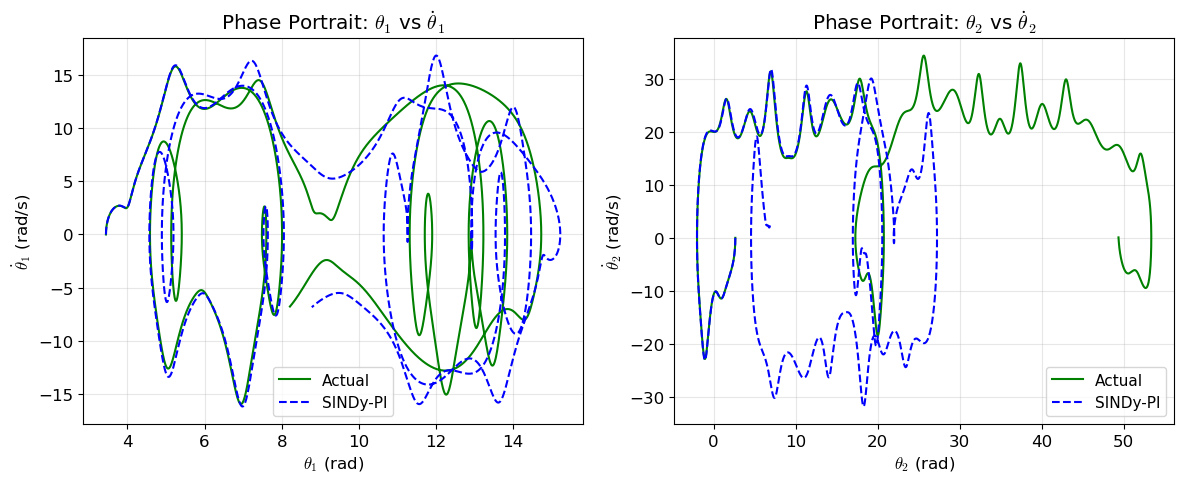

In [14]:
# Phase portrait comparison — MATLAB style: green solid truth, blue dashed SINDy-PI
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

n_phase = min(int(5.0 / dt), n)  # use first 5s for phase portraits

axes[0].plot(X_val[:n_phase, 0], X_val[:n_phase, 2], color='green', lw=1.5, label='Actual')
axes[0].plot(sol_sindy.y[0, :n_phase], sol_sindy.y[2, :n_phase], 'b--', lw=1.5, label='SINDy-PI')
axes[0].set_xlabel(r'$\theta_1$ (rad)', fontsize=12)
axes[0].set_ylabel(r'$\dot{\theta}_1$ (rad/s)', fontsize=12)
axes[0].set_title(r'Phase Portrait: $\theta_1$ vs $\dot{\theta}_1$')
axes[0].legend(fontsize=11); axes[0].grid(True, alpha=0.3)

axes[1].plot(X_val[:n_phase, 1], X_val[:n_phase, 3], color='green', lw=1.5, label='Actual')
axes[1].plot(sol_sindy.y[1, :n_phase], sol_sindy.y[3, :n_phase], 'b--', lw=1.5, label='SINDy-PI')
axes[1].set_xlabel(r'$\theta_2$ (rad)', fontsize=12)
axes[1].set_ylabel(r'$\dot{\theta}_2$ (rad/s)', fontsize=12)
axes[1].set_title(r'Phase Portrait: $\theta_2$ vs $\dot{\theta}_2$')
axes[1].legend(fontsize=11); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

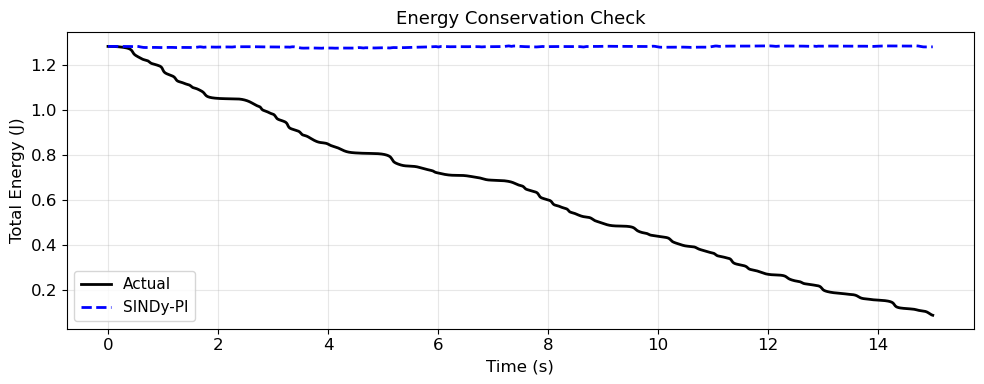

Initial energy error: 0.0000%


In [15]:
# Total mechanical energy comparison — physical consistency check
# If the discovered model respects the underlying physics, energy should decay
# at a similar rate to the true system (due to friction).

def compute_energy(y, m1, m2, a1, a2, L1, I1, I2, g):
    """Total mechanical energy: kinetic + potential."""
    phi1, phi2, w1, w2 = y[0], y[1], y[2], y[3]
    d = phi1 - phi2

    # Kinetic energy (mass matrix form)
    M11 = I1 + m1*a1**2 + m2*L1**2
    M12 = m2*L1*a2*np.cos(d)
    M22 = I2 + m2*a2**2
    T = 0.5*(M11*w1**2 + 2*M12*w1*w2 + M22*w2**2)

    # Potential energy (datum at pivot)
    V = -(m1*a1 + m2*L1)*g*np.cos(phi1) - m2*a2*g*np.cos(phi2)

    return T + V

E_true = np.array([compute_energy(X_val[i], m1, m2, a1, a2, L1, I1, I2, g)
                    for i in range(len(X_val))])
E_sindy = np.array([compute_energy(sol_sindy.y[:, i], m1, m2, a1, a2, L1, I1, I2, g)
                     for i in range(n)])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(t_val, E_true, 'k', lw=2, label='Actual')
ax.plot(sol_sindy.t[:n], E_sindy, 'b--', lw=2, label='SINDy-PI')
ax.set_xlabel('Time (s)', fontsize=12)
ax.set_ylabel('Total Energy (J)', fontsize=12)
ax.set_title('Energy Conservation Check', fontsize=13)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

E_err = abs(E_sindy[0] - E_true[0]) / abs(E_true[0])
print(f'Initial energy error: {E_err*100:.4f}%')